## Initialization

In [755]:
%load_ext autoreload
%autoreload 2

from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD
import matplotlib.pyplot as plt
import time
import numpy as np

LOG.propagate = False

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [766]:
# Get ArtemisBLEController object
ble = get_ble_controller()

# Connect to the Artemis Device
ble.connect()

2026-03-23 01:21:00,278 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:42:0c:78:b8:49
2026-03-23 01:21:00,279 | INFO     |: Scanning for device with address: c0:42:0c:78:b8:49, service UUID: d427e7cc-c400-4597-b417-d564e20d6600


2026-03-23 01:21:10,335 | INFO     |: Found 1 device(s) advertising service d427e7cc-c400-4597-b417-d564e20d6600
2026-03-23 01:21:10,337 | INFO     |: Selecting device: 3AE32BFA-4071-EC2D-ED7A-60CCA92DBE18 (name: Artemis BLE)
2026-03-23 01:21:11,158 | INFO     |: Connected to c0:42:0c:78:b8:49


In [596]:
ble.reload_config()

In [295]:
ble.stop_notify(ble.uuid["RX_STRING"])

## Start Record

In [757]:
times = []
left_motors = []
right_motors = []
error_values = []
integral_values = []
raw_integral_values=[]
derivative_values = []
raw_derivative_values = []
acc_x_values = []
tof_1_values = []
tof_2_values = []


def log_handler(sender, data: bytearray):
    parts = ble.bytearray_to_string(data).split("|")
    if len(parts) == 11:
        t = float(parts[0][2:])
        l = float(parts[1][3:])
        r = float(parts[2][3:])
        e = float(parts[3][2:])
        i = float(parts[4][2:])
        ri = float(parts[5][3:])
        d = float(parts[6][2:])
        rd = float(parts[7][3:])
        ax = float(parts[8][3:])
        t1 = float(parts[9][3:])
        t2 = float(parts[10][3:])

        times.append(t) # Convert microseconds to seconds
        left_motors.append(l)
        right_motors.append(r)
        error_values.append(e)
        integral_values.append(i)
        raw_integral_values.append(ri)
        derivative_values.append(d)
        raw_derivative_values.append(rd)
        acc_x_values.append(ax)
        tof_1_values.append(t1)
        tof_2_values.append(t2)
        print (f"t: {t:.2f}, lm: {l:.2f}, rm: {r:.2f}, e: {e:.2f}, i: {i:.2f},ri:{ri:.2f} d: {d:.2f}, rd: {rd:.2f}, ax: {ax:.2f},t1: {t1:.2f}, t2: {t2:.2f}")
    else:
        print(ble.bytearray_to_string(data))

In [767]:
ble.start_notify(ble.uuid["RX_STRING"], log_handler)


In [790]:
ble.send_command(CMD.SEND_LOG, "")

t: 9.00, lm: 255.00, rm: 255.00, e: -3193.00, i: 0.00,ri:0.00 d: 0.00, rd: 0.00, ax: -3.42,t1: 0.00, t2: 3497.00
t: 13.00, lm: 255.00, rm: 255.00, e: -3193.00, i: 0.00,ri:0.00 d: 0.00, rd: 0.00, ax: 81.05,t1: 0.00, t2: 3497.00
t: 16.00, lm: 255.00, rm: 255.00, e: -3193.00, i: 0.00,ri:0.00 d: 0.00, rd: 0.00, ax: 58.59,t1: 0.00, t2: 3497.00
t: 25.00, lm: 255.00, rm: 255.00, e: -3193.00, i: 0.00,ri:0.00 d: 0.00, rd: 0.00, ax: -1935.06,t1: 0.00, t2: 3497.00
t: 28.00, lm: 255.00, rm: 255.00, e: -3193.00, i: 0.00,ri:0.00 d: 0.00, rd: 0.00, ax: 378.91,t1: 0.00, t2: 3497.00
t: 36.00, lm: 255.00, rm: 255.00, e: -3193.00, i: 0.00,ri:0.00 d: 0.00, rd: 0.00, ax: 104.00,t1: 0.00, t2: 3497.00
t: 40.00, lm: 255.00, rm: 255.00, e: -3193.00, i: 0.00,ri:0.00 d: 0.00, rd: 0.00, ax: 543.95,t1: 0.00, t2: 3497.00
t: 43.00, lm: 255.00, rm: 255.00, e: -3193.00, i: 0.00,ri:0.00 d: 0.00, rd: 0.00, ax: -139.65,t1: 0.00, t2: 3497.00
t: 51.00, lm: 255.00, rm: 255.00, e: -3193.00, i: 0.00,ri:0.00 d: 0.00, rd: 0.00,

## Position Control

In [793]:
ble.send_command(CMD.SET_DURATION, "5000")
ble.send_command(CMD.SET_SETPOINT, "304")
ble.send_command(CMD.SET_MOTOR_SCALE, "1.0")
ble.send_command(CMD.UPDATE_PID, "0.05|0.0|0.05")
ble.send_command(CMD.SET_EXTRAPOLATION, "1")

In [794]:
times = []
left_motors = []
right_motors = []
error_values = []
integral_values = []
raw_integral_values = []
derivative_values = []
raw_derivative_values = []
acc_x_values = []
tof_1_values = []
tof_2_values = []

ble.send_command(CMD.START_RECORD, "")
time.sleep(6)
ble.send_command(CMD.SEND_LOG, "")

t: 9.00, lm: 255.00, rm: 255.00, e: -2996.00, i: 0.00,ri:0.00 d: 0.00, rd: 0.00, ax: -12.21,t1: 0.00, t2: 3300.00
t: 13.00, lm: 255.00, rm: 255.00, e: -2996.00, i: 0.00,ri:0.00 d: 0.00, rd: 0.00, ax: 9.77,t1: 0.00, t2: 3300.00
t: 21.00, lm: 255.00, rm: 255.00, e: -2996.00, i: 0.00,ri:0.00 d: 0.00, rd: 0.00, ax: -496.09,t1: 0.00, t2: 3300.00
t: 29.00, lm: 255.00, rm: 255.00, e: -2996.00, i: 0.00,ri:0.00 d: 0.00, rd: 0.00, ax: 1161.13,t1: 0.00, t2: 3300.00
t: 33.00, lm: 255.00, rm: 255.00, e: -2996.00, i: 0.00,ri:0.00 d: 0.00, rd: 0.00, ax: -216.31,t1: 0.00, t2: 3300.00
t: 41.00, lm: 255.00, rm: 255.00, e: -2996.00, i: 0.00,ri:0.00 d: 0.00, rd: 0.00, ax: 877.93,t1: 0.00, t2: 3300.00
t: 49.00, lm: 255.00, rm: 255.00, e: -2996.00, i: 0.00,ri:0.00 d: 0.00, rd: 0.00, ax: 670.90,t1: 0.00, t2: 3300.00
t: 53.00, lm: 255.00, rm: 255.00, e: -2996.00, i: 0.00,ri:0.00 d: 0.00, rd: 0.00, ax: -298.34,t1: 0.00, t2: 3300.00
t: 61.00, lm: 255.00, rm: 255.00, e: -2996.00, i: 0.00,ri:0.00 d: 0.00, rd: 0.0

In [164]:
ble.send_command(CMD.SEND_LOG, "")

## Graph

In [781]:
times = np.array(times)
left_motors = np.array(left_motors)
right_motors = np.array(right_motors)
error_values = np.array(error_values)
integral_values = np.array(integral_values)
raw_integral_values = np.array(raw_integral_values)
derivative_values = np.array(derivative_values)
raw_derivative_values = np.array(raw_derivative_values)
acc_x_values = np.array(acc_x_values)
tof_1_values = np.array(tof_1_values)
tof_2_values = np.array(tof_2_values)

In [783]:
np.savez("lab5/0.05_0_0.05_100pct_4m_E_2.npz",
    times=times,
    left_motors=left_motors,
    right_motors=right_motors,
    error_values=error_values,
    integral_values=integral_values,
    raw_integral_values=raw_integral_values,
    derivative_values=derivative_values,
    raw_derivative_values=raw_derivative_values,
    acc_x_values=acc_x_values,
    tof_1_values=tof_1_values,
    tof_2_values=tof_2_values
)

In [659]:
data = np.load("lab5/0.05_0_0.05_100pct_4m.npz")
times = data['times']
left_motors = data['left_motors']
right_motors = data['right_motors']
error_values = data['error_values']
integral_values = data['integral_values']
derivative_values = data['derivative_values']
raw_derivative_values = data['raw_derivative_values']
raw_integral_values = data['raw_integral_values']
acc_x_values = data['acc_x_values']
tof_1_values = data['tof_1_values']
tof_2_values = data['tof_2_values']

In [785]:
n = min(
    len(times), len(left_motors), len(right_motors),
    len(error_values), len(derivative_values),
    len(yaw_values), len(tof_1_values), len(tof_2_values)
)

times = times[:n]
left_motors = left_motors[:n]
right_motors = right_motors[:n]
error_values = error_values[:n]
derivative_values = derivative_values[:n]
raw_derivative_values = raw_derivative_values[:n]
integral_values = integral_values[:n]
raw_integral_values = raw_integral_values[:n]
acc_x_values = acc_x_values[:n]
tof_1_values = tof_1_values[:n]
tof_2_values = tof_2_values[:n]

In [784]:
vx = np.zeros_like(acc_x_values)
for i in range(1, len(times)):
    dt = (times[i] - times[i - 1])/ 1000.0
    if dt > 0:
        vx[i] = vx[i - 1] + acc_x_values[i]/1000.0 * 9.81 * dt
    else:
        vx[i] = vx[i - 1]


In [786]:
kp = 0.05
ki = 0.0
kd = 0.05

setpoint = 304.0
times = times / 1000.0
p_term = -kp * error_values
d_term = -kd * derivative_values
raw_d_term = -kd * raw_derivative_values
i_term = -ki * integral_values
raw_i_term = -ki * raw_integral_values

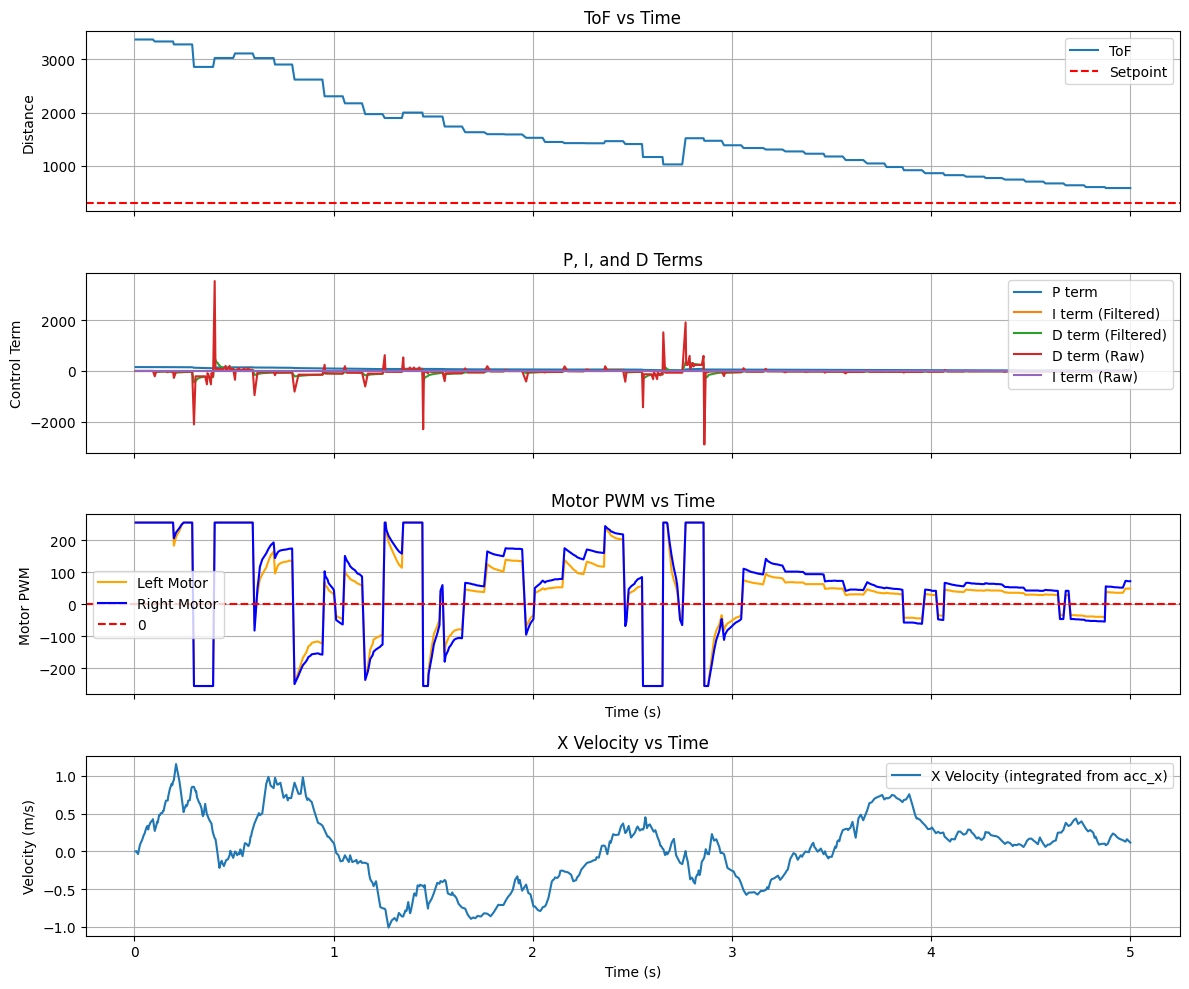

In [787]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# ToF
axes[0].plot(times, tof_2_values, label='ToF')
axes[0].axhline(setpoint, linestyle='--', label='Setpoint', color='red')
axes[0].set_ylabel('Distance')
axes[0].set_title('ToF vs Time')
axes[0].legend()
axes[0].grid(True)

# P, I, and D
axes[1].plot(times, p_term, label='P term')
axes[1].plot(times, i_term, label='I term (Filtered)')
axes[1].plot(times, d_term, label='D term (Filtered)')
axes[1].plot(times, raw_d_term, label='D term (Raw)')
axes[1].plot(times, raw_i_term, label='I term (Raw)')
axes[1].set_ylabel('Control Term')
axes[1].set_title('P, I, and D Terms')
axes[1].legend()
axes[1].grid(True)

# Motors
axes[2].plot(times, left_motors, label='Left Motor', color='orange')
axes[2].plot(times, right_motors, label='Right Motor', color='blue')
axes[2].axhline(0, linestyle='--', label='0', color='red')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Motor PWM')
axes[2].set_title('Motor PWM vs Time')
axes[2].legend()
axes[2].grid(True)

# 4. X velocity
axes[3].plot(times, vx, label='X Velocity (integrated from acc_x)')
axes[3].set_xlabel('Time (s)')
axes[3].set_ylabel('Velocity (m/s)')
axes[3].set_title('X Velocity vs Time')
axes[3].legend()
axes[3].grid(True)


plt.tight_layout()
plt.show()